<a href="https://colab.research.google.com/github/Valeriy1990/Else/blob/main/12_1_%D0%92%D0%B2%D0%B5%D0%B4%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B2_%D0%B0%D1%81%D0%B8%D0%BD%D1%85%D1%80%D0%BE%D0%BD%D0%BD%D0%BE%D0%B5_%D0%BF%D1%80%D0%BE%D0%B3%D1%80%D0%B0%D0%BC%D0%BC%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

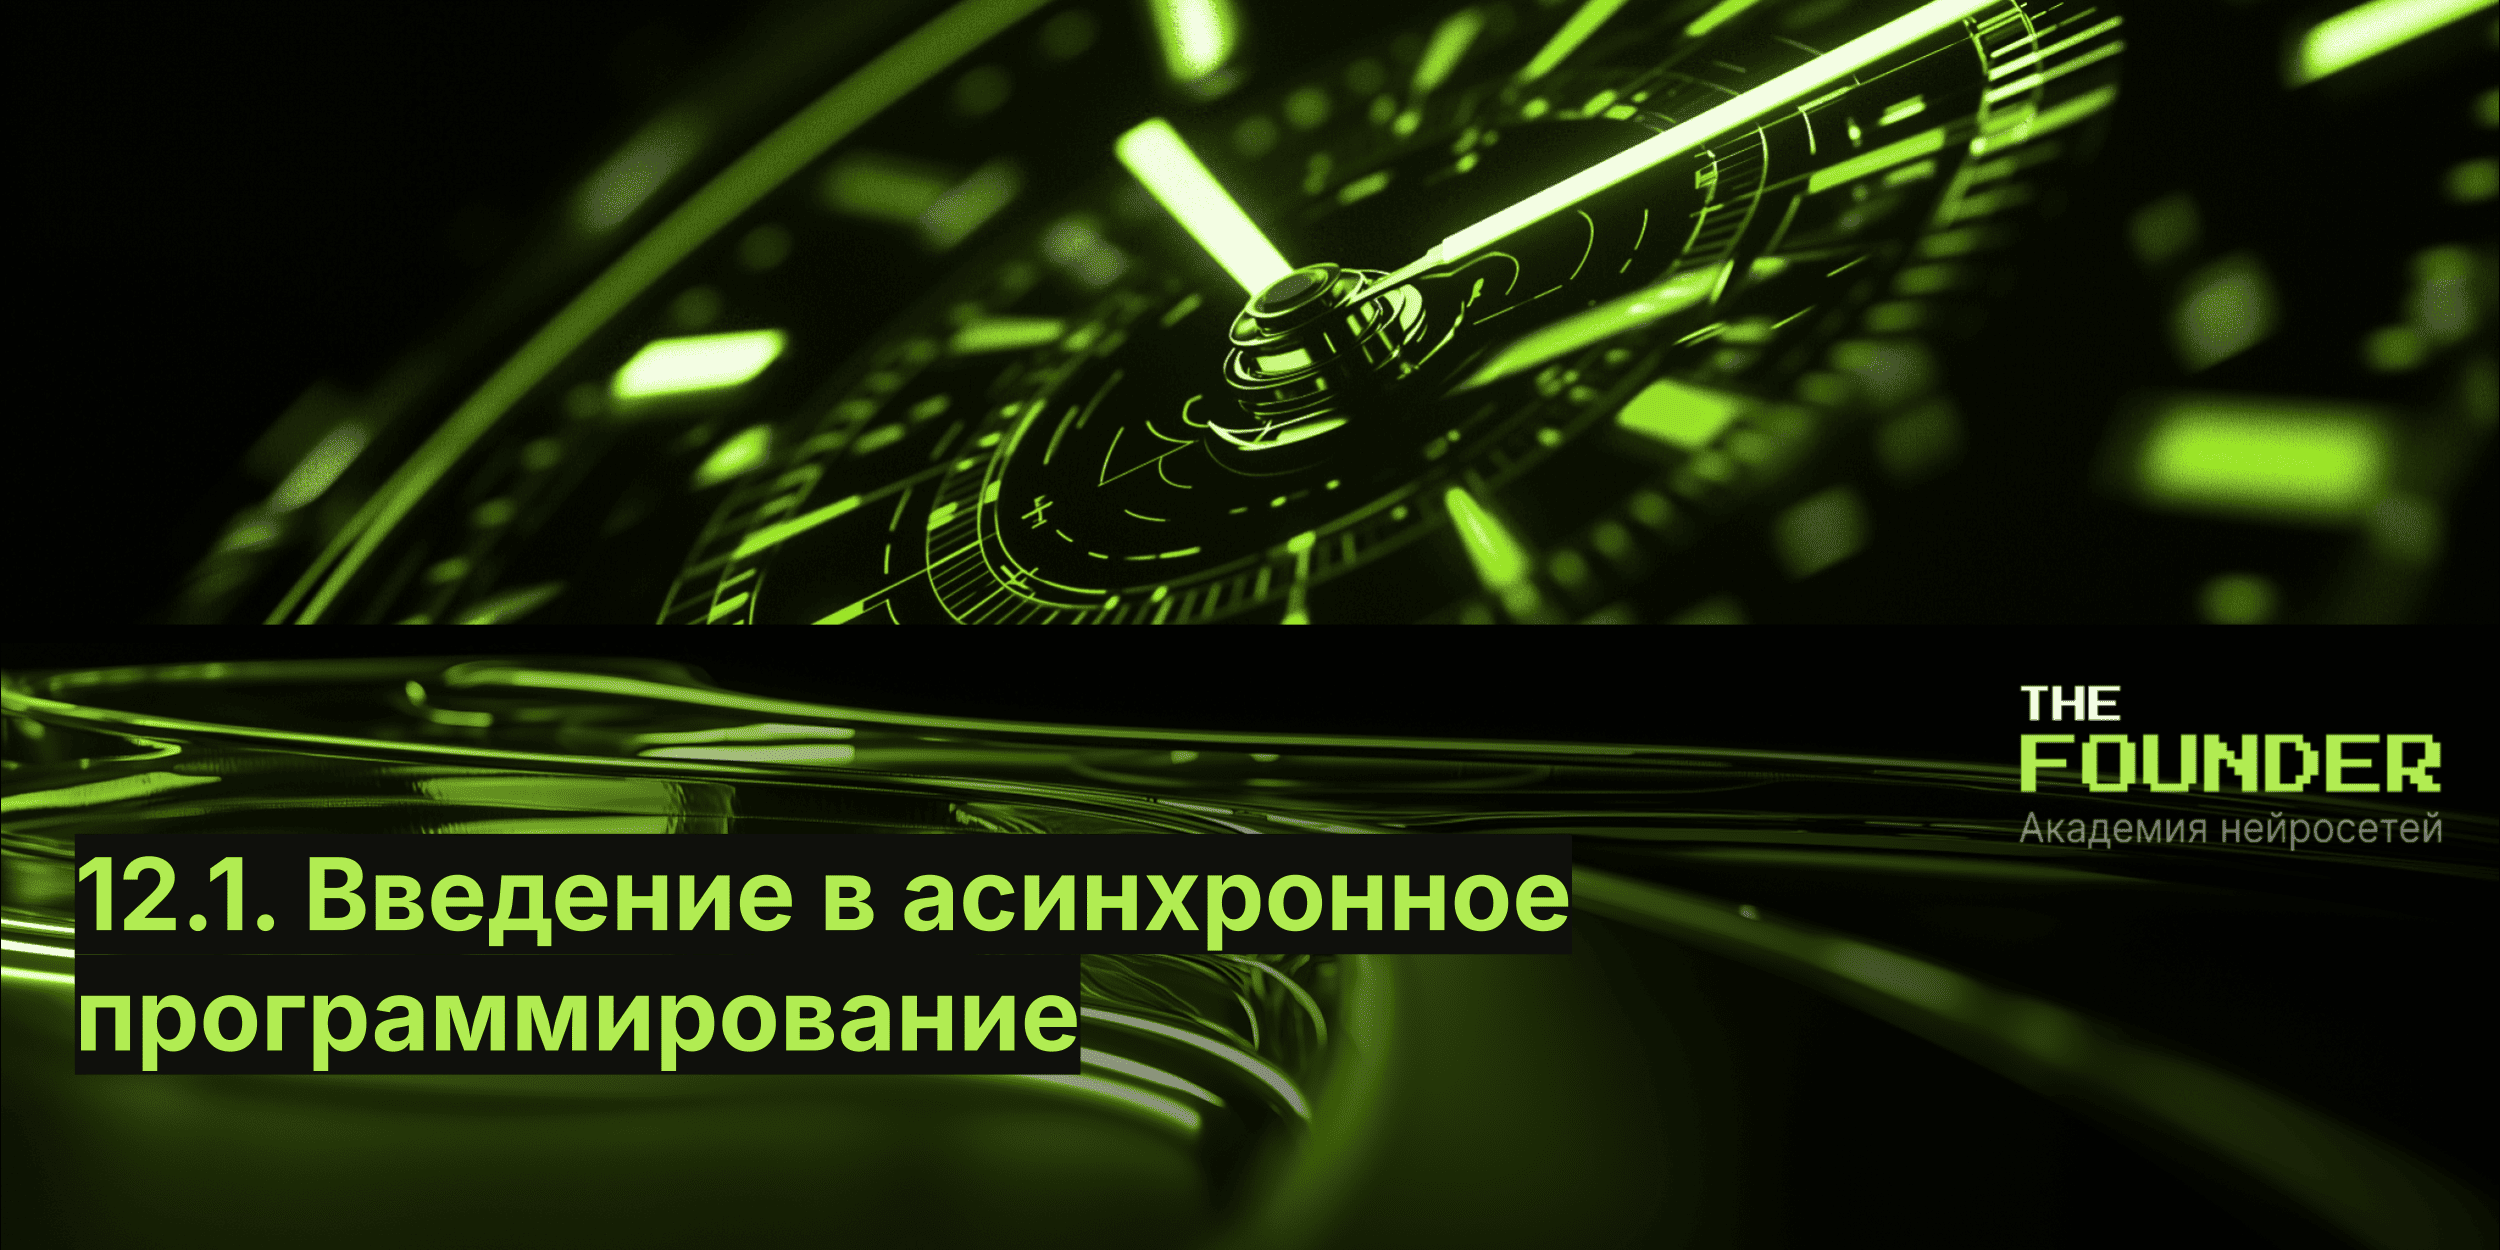

**Навигация по уроку**

1. Введение в асинхронное программирование
2. [Знакомство с библиотекой asyncio](https://colab.research.google.com/drive/1t5GZGzV9a3LZ-l_ZsTg9P8l5U-S_wOdh)
3. [Создание Telegram-бота с использованием aiogram3 и BotFather](https://colab.research.google.com/drive/1bgS8Uuqi2jrhqDAyaMmxhbOLJ3TvmKFC)
4. [Домашняя работа](https://colab.research.google.com/drive/1ylF61osqEgPqg4KgfmikbKMAyalhjBqv)

Если любую программу на Python подвергнуть высокой нагрузке, то она будет тормозить и медленно работать. Чтобы решить эту проблему была разработана библиотека `asyncio`, которая позволяет разбивать программу на мелкие задачи и планировать их выполнение. В результате приложения работают быстро и довольно легко масштабируются. В этом уроке мы рассмотрим, что такое асинхронное, параллельное и конкурентное программирование. Так что вперед за производительностью!

## Блокирующие операции ввода-вывода

Быстродействие многих программ, в частности веб-приложений, сильно зависят от операций ввода-вывода. Это могут быть операции скачивания веб-страниц из интернета, взаимодействие по сети с группой микросервисов или отправка запросов к базам данных (например, `MySQL` или `Postgres`). Выполнение веб-запроса или взаимодействие с микросервисом может занять несколько сотен миллисекунд или даже секунды, если сеть медленная. Запрос к базе данных может занимать много времени, особенно если нагрузка на базу высока или запрос сложный. Веб-серверу иногда приходится обрабатывать одновременно сотни или тысячи запросов.
Попытка выполнить эти запросы ввода-вывода сразу может привести к серьезным проблемам с производительностью. Если отправлять запросы один за другим, как в последовательном приложении, то замедление будет нарастать как "снежный ком".

Например, если мы пишем приложение, которое должно скачать 100 веб-страниц или выполнить 100 запросов к базе данных, и каждое взаимодействие продолжается 1 секунду, то для завершения приложения потребуется 100 секунд. Но если воспользоваться конкурентностью и начать все скачивания в одно и то же время, после чего дождаться результатов, то теоретически все операции можно
было бы завершить за 1 секунду.


## Что такое asyncio?

В синхронном приложении код исполняется последовательно. Следующая строка кода выполняется после завершения предыдущей, и  в  каждый момент времени происходит что-то одно. Эта модель хорошо работает для многих приложений.

Но что, если какая-то одна строка кода занимает слишком много времени? В таком случае весь последующий код должен будет замереть, пока эта строка не завершиться. Скорее всего вы встречали плохо написанные пользовательские интерфейсы, в  которых все сначала хорошо, а потом приложение внезапно зависало, оставляя нас созерцать крутящееся колесико или ждать хоть какого-нибудь ответа. Такие блокировки в приложении оставляют плохое впечатление у пользователя.

Любая достаточно длительная операция может блокировать приложение, но особенно часто это бывает, когда приложение ждет завершения ввода-вывода. Ввод-вывод выполняют такие устройства, как клавиатура, жесткий диск, сетевая карта. Такие
операции ждут ввода от пользователя или получения содержимого от веб-API.

В синхронном приложении мы будем ждать завершения операции и до тех пор ничего не сможем делать. Это ведет к проблемам с производительностью и отзывчивостью, поскольку в каждый момент времени может выполняться только одна длительная операция, а она не дает приложению больше ничего делать.

Один из способов решения этой проблемы  – ввести в  программу **конкурентность**, которая позволяет одновременно выполнять более одной задачи.

>Примерами конкурентного ввода-вывода могут служить одновременная отправка нескольких веб-запросов или создание одновременных подключений к веб-серверу.

В Python есть несколько способов организовать такую конкурентность. Одним из последних добавлений в экосистему Python является библиотека асинхронного ввода-вывода `asyncio`. Она позволяет исполнять код в рамках модели асинхронного программирования, т. е. производить сразу несколько операций ввода-вывода, не жертвуя отзывчивостью приложения.

**Так что же означают слова «асинхронное программирование»?**

Его стоит трактовать, как возможность длительной задачи выполняться в фоновом режиме отдельно от главного приложения. В таком случае, система не блокируется в ожидании завершения этой задачи, а может заниматься другими вещами, не зависящими от ее исхода. Затем, по завершении задачи, мы получим уведомление о том, что она все сделала, и сможем обработать результат.

Для организации асинхроности используются сопрограммы.

> **Сопрограмма** – это метод, который можно приостановить, если имеется потенциально длительная задача, а затем возобновить, когда она завершится.

Библиотека `asyncio` исполняет сопрограммы асинхронно, пользуясь моделью конкурентности, получившей название однопоточный цикл событий.

Название `asyncio` может навести на мысль, что библиотека подходит только для операций ввода-вывода. Но на самом деле она способна выполнять и  операции других типов, благодаря взаимодействию с  механизмами многопроцессности и  многопоточности. Библиотека пригодна не только для организации конкурентного ввода-вывода, но и для выполнения счетных задач, активно использующих процессор. Чтобы лучше разобраться в том, с какими рабочими нагрузками позволяет справляться `asyncio` и какая модель лучше всего подходит для каждого типа конкурентности, рассмотрим различия между операциями, ограниченными производительностью ввода-вывода и быстродействием процессора.

## Что такое ограниченность производительностью ввода-вывода и ограниченность быстродействием процессора?

Говоря, что операция ограничена производительностью ввода-вывода или быстродействием процессора, мы имеем в виду фактор, препятствующий более быстрой работе программы. Это значит, что если увеличить производительность того процесса, что ограничивает операцию, то для его завершения понадобится меньше времени.

* Операция, ограниченная быстродействием процессора (счетная операция),завершилась бы быстрее, будь процессор более мощным.
* Операция, ограниченная производительностью ввода-вывода, работала бы быстрее, если бы устройство могло обработать больше данных за меньшее время.

Для увеличения производительности ввода-вывода можно было бы увеличить пропускную способность сети, заплатив больше денег интернет-провайдеру или поставив более современную сетевую карту.

> **Счетные операции в Python** – это обычно вычисления и обработка данных.

Примерами счетных операций могут служить вычисления цифр числа $π$ или применение бизнес-логики к  каждому элементу словаря.

В  случае операции, ограниченной вводом-выводом, мы тратим большую часть
времени на ожидание ответа от сети или другого устройства. Примерами могут служить запрос к веб-серверу или чтение файла с жесткого диска. Операции, ограниченные производительностью ввода-вывода и быстродействием процессора, обычно сосуществуют бок о бок.

    Подытожим:

    Асинхронный ввод-вывод позволяет приостановить выполнение
    метода, встретив операцию ввода-вывода. Ожидая завершения этой
    операции, работающей в фоновом режиме, мы можем выполнять какой-нибудь
    другой код. Это позволяет выполнять одновременно много операций
    ввода-вывода и тем самым ускорить работу приложения.

## Конкурентность, параллелизм и многозадачность

Чтобы лучше понять, как конкурентность может повысить производительность приложения, важно для начала разобраться в терминологии конкурентного программирования. Давайте более детально разберемся, что такое «конкурентность» и как в `asyncio` используется концепция многозадачности для ее достижения.

Конкурентность и  параллелизм  – два понятия, помогающие понять, как осуществляется планирование программы и какие задачи, методы и процедуры приводят весь механизм в действие.

### Конкурентность

Говоря, что **две задачи выполняются конкурентно**, мы имеем в виду,
что они работают в одно и то же время. Взять, к примеру, пекаря, выпекающего два разных торта. Чтобы их испечь, нужно сначала разогреть духовку.

Разогрев может занимать десятки минут – это зависит от духовки и требуемой температуры, но нам необязательно ждать, пока духовка нагреется, поскольку можно в это время заняться другими делами, например смешать муку с сахаром и вбить в тесто яйца.
Это можно делать, пока духовка звуковым сигналом не известит нас о том, что нагрелась.

Мы также не хотим связывать себя ограничением – приступать ко второму торту только после готовности первого. Ничто не мешает замесить тесто для одного торта, положить его в миксер и начать готовить вторую порцию, пока первая взбивается. В  этой модели мы переключаемся между разными задачами конкурентно.

Такое переключение (делать что-то, пока духовка разогревается, переключаться
с одного торта на другой) – пример **конкурентного поведения**.

### Параллелизм

Хотя конкурентность подразумевает, что несколько задач выполняется одновременно, это еще не значит, что они работают параллельно.
Говоря о параллельной работе, мы имеем в виду, что две задачи или более не просто чередуются, а выполняются строго в одно и то же время.
Возвращаясь к  примеру с  тортами, представьте, что мы призвали
на помощь второго пекаря. В этом случае мы можем трудиться над
первым тортом, а помощник будет заниматься вторым. Два человека,
готовящих тесто, работают параллельно, потому что одновременно
делают два разных дела (рис. 1).

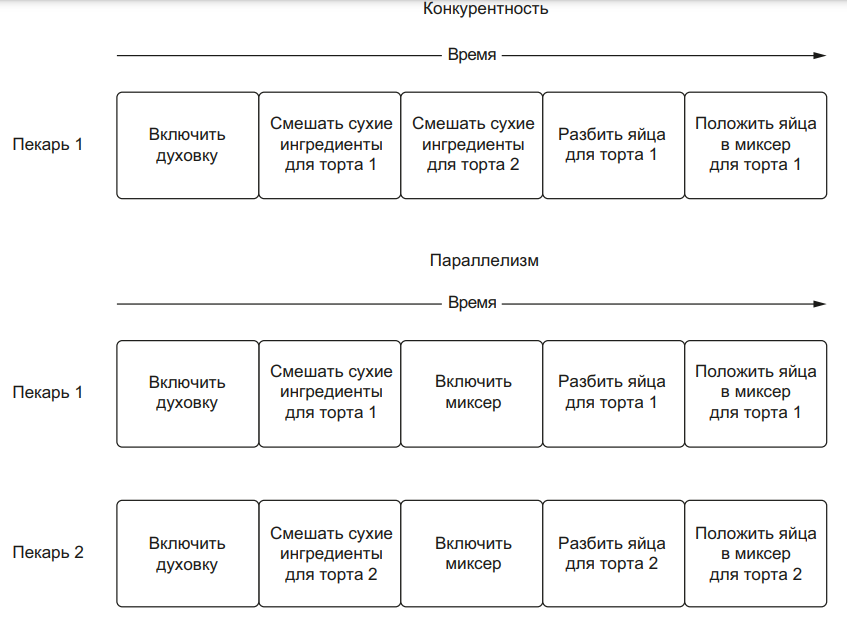

    В случае конкурентности несколько задач работает в течение одного промежутка времени, но только одна активна в каждый момент.

    В случае параллелизма несколько задач активны одновременно.

**Рис. 1. Сравнение конкурентности и параллелизма**

Теперь переведем это на язык приложений, исполняемых операционной системой. Пусть работают два приложения. В конкурентной системе мы можем переключаться между ними, дав немного поработать сначала одному, а потом другому. Если делать это достаточно быстро, создается впечатление, что два дела делаются одновременно.

В  параллельной системе два приложения работают действительно одновременно, т. е. оба активны в одно и то же время.

Понятия конкурентности и параллелизма похожи, и различить их бывает затруднительно, но важно хорошо понимать, чем они отличаются.

    В случае конкурентности мы переключаемся между приложениями.

    В случае параллелизма мы активно выполняем приложения одновременно.

### Различие между конкурентностью и параллелизмом

Конкурентность возможна, когда несколько задач может работать независимо друг от друга. Конкурентность можно организовать, имея
процессор всего с одним ядром, применив **вытесняющую многозадачность** для переключения между задачами. С другой стороны, параллелизм означает, что мы должны выполнять две задачи и более строго одновременно. На машине с одним ядром это невозможно, необходимо иметь процессор с несколькими ядрами. Как в примере выше, сколько ядер, столько мы можем задействовать и поваров.

Параллелизм подразумевает конкурентность, но обратное верно не всегда. Многопоточное приложение, работающее на многоядерной машине, является и конкурентным, и параллельным. В этом случае имеется несколько задач, работающих одновременно, и два ядра, независимо исполняющих код этих задач. Но многозадачность допускает также наличие нескольких задач, работающих конкурентно, но так, что в каждый момент времени выполняется только одна.

### Что такое многозадачность?

В современном мире многозадачность встречается повсеместно. Мы
готовим завтрак, а  пока в  чайнике закипает вода, кому-то звоним
или отвечаем на текстовое сообщение. А пока электричка везет нас
на работу, читаем книгу. В этом разделе мы обсудим два основных
вида многозадачности: **вытесняющую** и **кооперативную** (невытесняющую).

**Вытесняющая многозадачность**

В этой модели мы позволяем операционной системе решить, как переключаться между выполняемыми задачами с помощью процедуры квантования времени (на простом языке - распределение времени с определенными порциями). Когда операционная система переключает задачи, мы говорим, что имеет  место вытеснение.
Как устроен этот механизм, зависит от операционной системы.
Обычно для этого используется либо несколько потоков, либо несколько процессов.

**Кооперативная многозадачность**

В этой модели мы не полагаемся для переключения между задачами на операционную систему, а явно определяем в коде приложения
точки, где можно уступить управление другой задаче. Исполняемые
задачи кооперируются, т. е. говорят приложению: «Я сейчас на время
приостановлюсь, а ты можешь пока выполнять другие задачи».


В `asyncio` для организации конкурентности используется кооперативная многозадачность. Когда приложение доходит до точки, в которой может подождать результата, мы явно помечаем это в коде. Поэтому другой код может работать, пока мы ждем получения результата, вычисляемого в фоновом режиме. Как только вычисление результата завершится, мы «просыпаемся» и возобновляем задачу. Это является формой конкурентности, потому что несколько задач может работать
одновременно, но – и это очень важно – не параллельно, так как их выполнение чередуется.

У кооперативной многозадачности есть ряд преимуществ перед вытесняющей:

* **потребляет меньше ресурсов**. Когда операционной системе нужно переключиться между потоками или процессами, то имеет место контекстное переключение. Это трудоемкая операция, потому что операционная система должна сохранить всю информацию о работающем процессе или потоке, чтобы потом его можно было возобновить.

* **гранулярность**. Операционная система приостанавливает поток или процесс в соответствии со своим алгоритмом планирования, но выбранный для этого момент не всегда оптимален. В случае кооперативной многозадачности мы явно помечаем точки, в которых приостановить задачу наиболее выгодно. Это дает выигрыш в эффективности, потому что мы переключаем задачи именно в тот момент, когда это нужно.


А теперь, когда мы разобрались в понятиях конкурентности, параллелизма и многозадачности, посмотрим, как они реализуются в Python с помощью потоков и процессов.

## Процессы, потоки, многопоточность и многопроцессность в Python

Чтобы лучше понять, как работает конкурентность в  Python, нужно
сначала разобраться с потоками и процессами. Затем мы поговорим
о  том, как использовать их для организации конкурентной работы
с помощью многопоточности и многозадачности. Начнем с определения процесса и потока.

### Процесс

> Процессом называется работающее приложение, которому выделена
область памяти, недоступная другим приложениям.

Пример создания Python-процесса – запуск простого приложения «Hello World!».

На одной машине может работать несколько процессов. Если машина оснащена процессором с несколькими ядрами, то несколько процессов могут работать одновременно. Если процессор имеет только одно ядро, то все равно можно выполнять несколько приложений конкурентно, но уже с применением квантования времени.

При использовании квантования операционная система будет автоматически вытеснять работающий процесс по истечении некоторого промежутка времени и  передавать процессор другому процессу.

Алгоритмы, определяющие, в какой момент переключать процессы, зависят от операционной системы.

### Поток

Потоки можно представлять себе как облегченные процессы. Кроме
того, это наименьшая единица выполнения, которая может управляться операционной системой. У  потоков нет своей памяти, они
пользуются памятью создавшего их процесса. Потоки ассоциированы с процессом, создавшим их. С каждым процессом всегда ассоциирован по меньшей мере один поток, обычно называемый главным (см. рис. 2).

Процесс может создавать дополнительные потоки, которые обычно называются рабочими или фоновыми. Эти потоки могут конкурентно выполнять другую работу наряду с главным потоком. Потоки, как и  процессы, могут работать параллельно на многоядерном процессе, и операционная система может переключаться между ними с помощью квантования времени. Обычное Python-приложение создает процесс и главный поток, который отвечает за его выполнение.

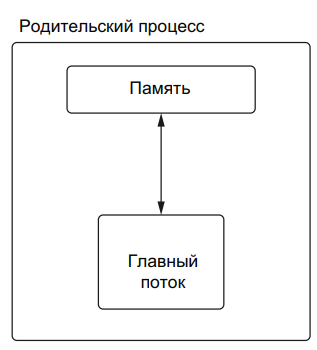

**Рис. 2. Процесс с одним главным потоком, читающий данные из памяти, выделенной всему процессу**

Приведем пример кода, демонстрирующий работу главного потока.

In [ ]:
import os
import threading # библиотека для работы с потоками

print(f'Исполняется Python-процесс с идентификатором: {os.getpid()}')

# Получаем счетчик активных потоков
total_threads = threading.active_count()

# Получаем имя текущего потока
thread_name = threading.current_thread().name

print(f'В данный момент Python исполняет {total_threads} поток(ов)')
print(f'Имя текущего потока {thread_name}')

Исполняется Python-процесс с идентификатором: 829
В данный момент Python исполняет 5 поток(ов)
Имя текущего потока MainThread


Сначала мы получаем уникальный идентификатор процесса и печатаем его, чтобы доказать, что действительно имеется работающий процесс. Затем получаем счетчик активных потоков и имя текущего потока, чтобы доказать, что действительно
работает один поток – главный. При каждом выполнении этой программы идентификатор процесса будет разным.

Процессы могут порождать дополнительные потоки, разделяющие
память со своим процессом-родителем. Они могут конкурентно выполнять другую работу, это называется многопоточностью.

Создадим простое многопоточное приложение:

In [ ]:
import threading

def hello_from_thread():
    print(f'Привет от потока {threading.current_thread()}!')

# Создаем новый поток, который выполняет функцию hello_from_thread
hello_thread = threading.Thread(target=hello_from_thread)

# Запускаем поток
hello_thread.start()

# Получаем счетчик активных потоков
total_threads = threading.active_count()

# Получаем имя текущего потока
thread_name = threading.current_thread().name

print(f'В данный момент Python выполняет {total_threads} поток(ов)')
print(f'Имя текущего потока {thread_name}')

# Приостановка программы
hello_thread.join()

Привет от потока <Thread(Thread-10 (hello_from_thread), started 135311803807296)>!
В данный момент Python выполняет 5 поток(ов)
Имя текущего потока MainThread


Мы объявили функцию, которая печатает текущий поток, а затем создали поток, исполняющий ее. После этого вызывается метод потока `start`, запускающий поток. А в конце вызывается метод `join`, который приостанавливает программу, до тех пор пока указанный поток не завершится.

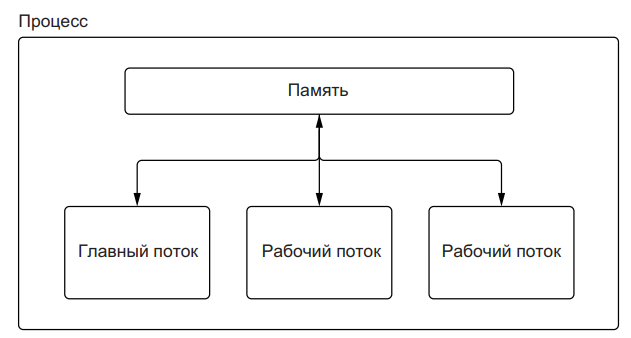

**Рис. 3. Пример многопоточной программы. Все потоки используют общую память процесса**

Многопоточные приложения – обычный способ реализации конкурентности во многих языках программирования. Но в Python есть несколько препятствий на пути организации конкурентности с по­мощью потоков.

Многопоточность полезна только для задач, ограниченных производительностью ввода-вывода, потому что нам мешает глобальная блокировка интерпретатора, о которой пойдет речь немного позже.

Многопоточность не единственный способ добиться конкурентности. Можно вместо потоков создать несколько конкурентных процессов, это называется многопроцессностью. В таком случае родительский процесс создает один или более дочерних процессов, которыми управляет, а затем распределяет между ними работу.
В Python для этой цели имеется модуль `multiprocessing`. Его API похож на API модуля `threading`. Сначала создается процесс, при этом передается функция `target`. Затем вызывается метод `start`, чтобы начать выполнение процесса, и в конце – метод `join`, чтобы дождаться его завершения.

In [ ]:
import multiprocessing
import os

def hello_from_process():
    print(f'Привет от дочернего процесса {os.getpid()}!')

# Создание дочернего процесса
hello_process = multiprocessing.Process(target=hello_from_process)

# Запуск дочернего процесса
hello_process.start()

print(f'Привет от родительского процесса {os.getpid()}')

# Дожидаемся завершение процесса
hello_process.join()

Привет от дочернего процесса 552!
Привет от родительского процесса 477


Мы создаем один дочерний процесс, который печатает свой идентификатор, а также печатаем идентификатор родительского процесса, чтобы доказать, что работают два разных процесса. Многопроцессность обычно предпочтительна, когда имеется счетная задача.

Мы можем добавлять сколько угодно новых дочерних процессов. На рис. 4 схематически показан пример с двумя дочерними процессами и потоками для них.

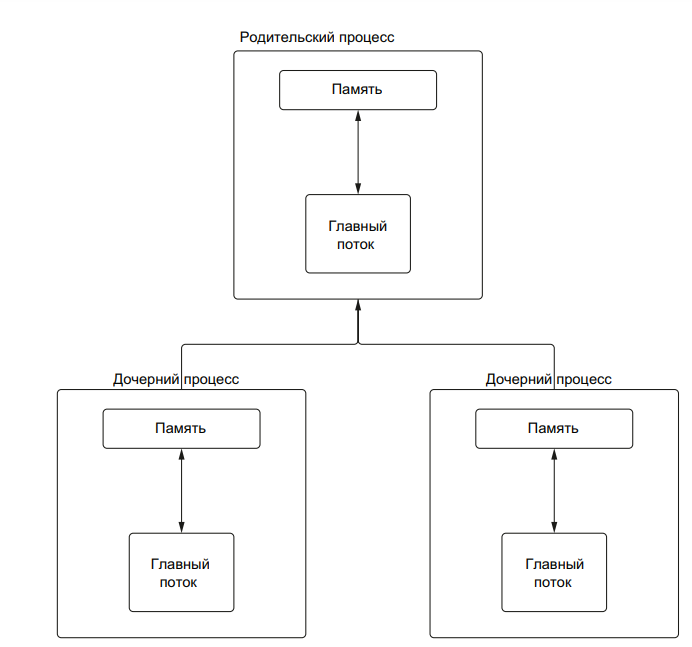

**Рис. 4. Пример приложения с одним родительским процессом и двумя дочерними**

Многопоточность и многопроцессность могут показаться волшебной палочкой, обеспечивающей конкурентность в  Python. Однако развернуться во всю мощь этим моделям мешает одна деталь реализации Python – глобальная блокировка интерпретатора.

### Глобальная блокировка интерпретатора

Глобальная блокировка интерпретатора (GIL) не дает Python-процессу исполнять более одной команды байт-кода в каждый момент времени. Это означает, что, даже если имеется несколько потоков на многоядерной машине, интерпретатор сможет
в каждый момент исполнять только один поток, содержащий написанный на Python код. В мире, где процессоры имеют несколько ядер, это создает серьезную проблему для разработчиков на Python, желающих воспользоваться многопоточностью для повышения производительности приложений.

> Многопроцессные приложения могут конкурентно выполнять несколько команд байт-кода, потому что у каждого Python-процесса своя собственная GIL.

**Так для чего же нужна GIL?**

Ответ кроется в том, как CPython управляет памятью.

>**CPython** – это эталонная реализация Python, т. е. стандартная реализация
языка, которая используется как эталон правильного поведения. Существуют и другие реализации, например Jython, работающая под управлением виртуальной машины Java, или IronPython, предназначенная для .NET Framework.

В CPython память управляется в основном с помощью подсчета ссылок. То есть для каждого объекта Python, например целого числа, словаря или списка подсчитывается, сколько объектов в данный момент используют его. Когда объект перестает быть нужным, счетчик ссылок на него уменьшается, а когда появляется новое обращение к объекту, счетчик ссылок увеличивается. Если счетчик ссылок обратился в нуль, значит, на объект никто не ссылается, поэтому его можно удалить из памяти.

Конфликт потоков возникает из-за того, что интерпретатор CPython не является потокобезопасным. Это означает, что если два или более потоков модифицируют разделяемую переменную, то ее конечное состояние может оказаться неожиданным, поскольку зависит от порядка доступа к  переменной со стороны потоков. Эта
ситуация называется **состоянием гонки**. Состояния гонки могут возникать, когда два потока одновременно обращаются к одному объекту Python.

Если два потока одновременно увеличивают счетчик ссылок, то может так случиться, что счетчик обнулится, хотя объект еще используется. Результатом станет крах приложения при попытке прочитать данные из освобожденной памяти.

Возникает вопрос, возможна ли вообще многопоточная конкурентность в Python, раз GIL запрещает одновременное выполнение двух строк Python-кода?

Но GIL не удерживается постоянно, а это открывает возможность использования нескольких потоков.

Глобальная блокировка интерпретатора освобождается на время выполнения операций ввода-вывода. Это позволяет использовать потоки для конкурентного выполнения ввода-вывода, но не для выполнения счетного кода, написанного на Python, хотя есть и исключения, когда GIL все же освобождается на время выполнения счетных задач.


**Так почему же GIL освобождается при вводе-выводе, но не освобождается для счетных задач?**

Все дело в системных вызовах, которые выполняются за кулисами. В  случае ввода-вывода низкоуровневые системные вызовы работают за пределами среды выполнения Python.

Это позволяет освободить GIL, потому что код операционной системы не взаимодействует напрямую с объектами Python. GIL захватывается снова, только когда полученные данные переносятся в объект Python. Стало быть, на уровне ОС операции ввода-вывода выполняются конкурентно. Эта модель обеспечивает конкурентность, но не параллелизм. В других языках, например Java или C++, на многоядерных машинах можно организовать истинный параллелизм, потому что никакой GIL нет и код может выполняться строго одновременно.

Но в  Python лучшее, на что можно рассчитывать, – конкурентность операций ввода-вывода, поскольку в  любой момент может выполняться только один кусок написанного на Python кода.

**Аsyncio и GIL**

В `asyncio` используется тот факт, что операции ввода-вывода освобождают GIL, что позволяет реализовать конкурентность даже в  одном потоке. При работе с `asyncio` мы создаем объекты сопрограмм. Сопрограмму можно представлять себе как облегченный поток. Точно так же, как может быть несколько потоков, работающих одновременно и исполняющих разные операции ввода-вывода, так может существовать много сопрограмм, работающих бок о бок. Ожидая завершения
сопрограмм, занимающихся вводом-выводом, мы можем выполнять другой Python-код, получая таким образом конкурентность. Важно отметить, что `asyncio` не обходит GIL, мы по-прежнему ограничены ей.

Если имеется счетная задача, то для ее конкурентного выполнения все равно нужно заводить отдельный процесс, иначе производительность снизится.

## Операции ввода-вывода и сокеты

**Сокет** – это низкоуровневая абстракция отправки и получения данных по сети.

Именно с их помощью производится обмен данными между клиентами и  серверами.

Сокеты поддерживают две основные операции: отправку и получение байтов. Мы записываем байты в сокет, затем они передаются по адресу назначения, чаще всего на какой-то сервер. Отправив байты, мы ждем, пока сервер пришлет ответ в наш сокет. Когда байты окажутся в сокете, мы сможем прочитать результат.

> Низкоуровневую концепцию сокетов проще понять, если представлять их как почтовые ящики. Вы можете положить письмо в почтовый ящик, почтальон заберет его и  доставит в  почтовый ящик получателя. Получатель откроет его и достанет ваше письмо. В зависимости от содержания письма получатель может отправить письмо в ответ. Здесь письмо является аналогом данных или байтов, которые
мы хотим отправить. Можно рассматривать помещение письма в почтовый ящик как запись байтов в сокет, а извлечение его из ящика – как чтение байтов из сокета. Почтальон тогда является аналогом механизма передачи через интернет, который маршрутизирует данные до адреса назначения.

Если нужно получить содержимое страницы https://vk.com/, то мы открываем сокет, подключенный к серверу https://vk.com/. Затем записываем в сокет запрос и ждем ответа от сервера, в данном случае HTML-кода веб-страницы.



### Блокирующие и неблокирующие сокеты

По умолчанию сокеты **блокирующие**. Это значит, что на все время ожидания ответа от сервера приложение приостанавливается или блокируется. Следовательно, оно не может ничего делать, пока не придут данные от сервера или произойдет ошибка или случится тайм-аут.

На уровне операционной системы эта блокировка ни к чему. Сокеты могут работать в **неблокирующем режиме**, когда мы просто начинаем операцию чтения или записи и забываем о ней, а сами занимаемся другими делами. Но позже операционная система уведомляет нас о том, что байты получены, и в этот момент мы можем уделить им внимание.

Это позволяет приложению не ждать прихода байтов, а делать что-то полезное. Для реализации такой схемы применяются различные системы уведомления с помощью событий, разные в разных операционных системах (ОС).

Библиотека `asyncio` позволяет абстрагироваться от различий между уведомлениями в различных ОС.

Эти системы уведомлений, независимо от ОС, наблюдают за неблокирующими сокетами и уведомляют нас, когда с сокетом можно начинать работу. Именно они лежат
в  основе модели конкурентности в `asyncio`. В этой модели имеется только один поток, исполняющий Python-код. Встретив операцию ввода-вывода, интерпретатор передает ее на попечение системы уведомления, входящей в состав ОС. Совершив этот акт, поток Python волен исполнять другой код или открыть другие неблокирующие сокеты, о которых позаботится ОС. По завершении операции система
«пробуждает» задачу, ожидающую результата, после чего выполняется код, следующий за этой операцией.

Эта схема изображена на рис. 5, где имеется несколько операций с разными сокетами.

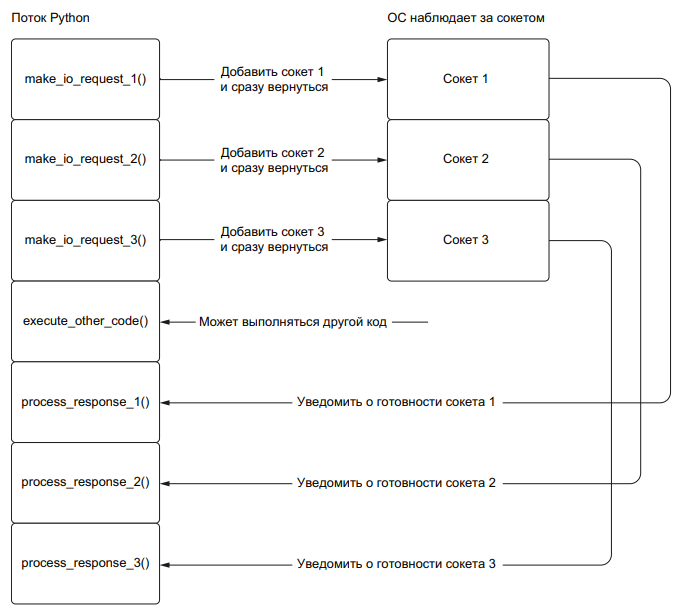

Здесь используются 3 абстракных метода:
* `make_io_request()` - послать в сокет данные
* `execute_other_code()` - выполнить другой
* `proccess_response()` - обработать уведомление от сокета

**Рис. 5. Взаимодействие потока Python с сокетами в ОС**

После записи запроса в неблокирующий сокет управление возвращается
немедленно, а ОС начинает наблюдать за данными в сокете. Поэтому функция
`execute_other_code()` начинает выполняться сразу, не дожидаясь завершения операции ввода-вывода. Когда операция завершится, мы получим уведомление и сможем обработать ответ.

Но как теперь отличить задачи, ожидающие завершения ввода-вывода, от тех, которые просто выполняют Python-код и ничего не ждут?
Ответ дает конструкция под названием «цикл событий», с которой вы позномитесь в следующем Блокноте.

## Основные выводы

Асинхронное программирование является одной из самых сложных и запутанных тем в программировании. И чтобы не потеряться в терминах и определениях, давайте сделаем промежуточные выводы, прежде чем перейти к изучению самой библиотеки `asyncio`.

* Ограниченной быстродействием процессора (счетной) называется работа, потребляющая в основном ресурсы процессора.
* Ограниченной производительностью ввода-вывода называется работа, потребляющая в основном ресурсы сети или других устройств ввода-вывода.
* Главная задача библиотеки `asyncio`  – обеспечить конкурентность задач, ограниченных производительностью ввода-вывода, однако она также предлагает API для организации конкурентности счетных задач.
* Процессы и потоки – основные единицы конкурентности на уровне операционной системы.
* Процессы можно использовать для рабочих нагрузок, ограниченных как производительностью ввода-вывода, так и быстродействием процессора.
* Потоки в Python обычно используются только для эффективного управления задачами, ограниченными производительностью ввода-вывода, потому что GIL
не дает выполнять код параллельно.



А теперь [перейдем](https://colab.research.google.com/drive/1t5GZGzV9a3LZ-l_ZsTg9P8l5U-S_wOdh) к изучению самой библиотеки асинхронного программирования в Python - `asyncio`.